# Weather Effects on F1 Lap Performance: A Guided Walkthrough

Two symmetric studies on the 2022–2025 ground-effect era, sharing one OOP backbone (`f1lab`):

| Study | Causal axis | Train (2022–2024) | In-domain test (2025) | Cross-domain test (2025) |
|---|---|---|---|---|
| **wind** | `HeadWind`, `CrossWind` | Azerbaijan (Baku) | Azerbaijan | Saudi Arabia (Jeddah) |
| **temp** | `AirTemp`, `TrackTemp` | Singapore | Singapore | Las Vegas |

Both studies predict `LapTimeDelta` (lap time above the driver-stint best, in seconds) from 11 features: 9 shared baseline controls plus the 2 features each study claims as cause. Anything in the baseline is a control variable; anything study-specific is the mechanism under investigation.

**The design position:** a regression will emit a number for any input, so *knowing when not to predict* has to be built, not hoped for. Below, the wind model meets a physics-compatible street circuit and generalizes; the temp model meets a track 10 °C colder than anything it trained on and *refuses* to correct a strategy decision rather than silently extrapolating. That asymmetry is the core result.

This notebook runs top-to-bottom in a few minutes: pretrained models (`models/*.joblib`) + committed merged data (`data/merged/*.xlsx`). No training, no network.

## 1. Setup

The bootstrap mirrors `tests/conftest.py`: add the project root to `sys.path` so the notebook runs straight from a clone, no `pip install` required. Everything imports from the `f1lab` facade.

In [1]:
%matplotlib inline
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "f1lab").is_dir():  # notebook lives in notebooks/
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd

from f1lab import ModelEvaluator, TempPreprocessor, UndercutScenario, Visualizer, WindPreprocessor

# Known-cosmetic legend warning emitted by the ICE overlay.
warnings.filterwarnings("ignore", message="No artists with labels")

DATA = PROJECT_ROOT / "data" / "merged"
MODELS = PROJECT_ROOT / "models"
print(f"project root : {PROJECT_ROOT.name}")
print(f"models found : {sorted(p.name for p in MODELS.glob('*_rf.joblib'))}")

project root : F1
models found : ['azerbaijan_rf.joblib', 'singapore_rf.joblib']


## 2. Load and preprocess the training data

`BaseLapPreprocessor.run()` is a locked Template Method: sort, engineer stint features on *unfiltered* laps, drop pit and non-green-flag laps (plus the lap after each), compute the target, build the feature matrix. The two subclasses differ only in the causal axis they add on top of the shared 9-feature baseline.

Expected shapes: wind `X = (2248, 13)`, temp `X = (2366, 14)`. Both carry the same 11 features; the widths differ only because one-hot `Compound` expands to however many compounds each venue actually ran.

In [2]:
_, x_wind, y_wind = WindPreprocessor.from_excel(DATA / "2022-2024_Azerbaijan_Grand_Prix.xlsx").run()
_, x_temp, y_temp = TempPreprocessor.from_excel(DATA / "2022-2024_Singapore_Grand_Prix.xlsx").run()

print(f"wind (Azerbaijan 2022-2024): X={x_wind.shape}, y={y_wind.shape}")
print(f"temp (Singapore 2022-2024):  X={x_temp.shape}, y={y_temp.shape}")
x_wind.head()

wind (Azerbaijan 2022-2024): X=(2248, 13), y=(2248,)
temp (Singapore 2022-2024):  X=(2366, 14), y=(2366,)


,LapNumber,LapInStint,TyreLife,TyreLifeNorm,FreshTyre,FuelLoad,Humidity,Rainfall,HeadWind,CrossWind,Compound_HARD,Compound_MEDIUM,Compound_SOFT
14,1.0,1.0,1.0,0.111111,1.0,108.3,57.0,0.0,0.008726,-0.499924,0.0,1.0,0.0
34,2.0,2.0,2.0,0.222222,1.0,106.6,56.0,0.0,-0.290306,-1.164355,0.0,1.0,0.0
54,3.0,3.0,3.0,0.333333,1.0,104.9,56.0,0.0,-0.290306,-1.164355,0.0,1.0,0.0
74,4.0,4.0,4.0,0.444444,1.0,103.2,56.0,0.0,-0.290306,-1.164355,0.0,1.0,0.0
94,5.0,5.0,5.0,0.555556,1.0,101.5,59.0,0.0,0.817183,-1.603812,0.0,1.0,0.0


## 3. The headline contrast: 2025 evaluation

Methodology guard: models train on 2022–2024 only (`TimeSeriesSplit` CV inside the first 80%, last 20% held out for model selection); the full 2025 races stay truly unseen. RF is the common main model in both studies.

Each study's RF is evaluated on its 2025 in-domain race and its 2025 cross-domain race, raw and with median-residual bias correction. Year-on-year drift within one regulatory era is a finding, handled post hoc, never by mixing 2025 into training.

In [3]:
wind_eval = ModelEvaluator(MODELS / "azerbaijan_rf.joblib", WindPreprocessor)
temp_eval = ModelEvaluator(MODELS / "singapore_rf.joblib", TempPreprocessor)

runs = [
    ("wind", "in-domain: Azerbaijan 2025", wind_eval, "2025_Azerbaijan_Grand_Prix.xlsx"),
    ("wind", "cross-domain: Saudi Arabia 2025", wind_eval, "2025_Saudi_Arabian_Grand_Prix.xlsx"),
    ("temp", "in-domain: Singapore 2025", temp_eval, "2025_Singapore_Grand_Prix.xlsx"),
    ("temp", "cross-domain: Las Vegas 2025", temp_eval, "2025_Las_Vegas_Grand_Prix.xlsx"),
]

rows = []
for study, setting, evaluator, filename in runs:
    print(f"--- {study} | {setting} ---")
    res = evaluator.evaluate(DATA / filename, bias_correct=True)
    print()
    rows.append({
        "study": study,
        "setting": setting,
        "R2 (raw)": round(res.metrics.r2, 3),
        "MAE (raw)": round(res.metrics.mae, 3),
        "RMSE (raw)": round(res.metrics.rmse, 3),
        "bias offset (s)": round(res.bias_offset, 2),
        "R2 (corrected)": round(res.metrics_corrected.r2, 3),
        "MAE (corrected)": round(res.metrics_corrected.mae, 3),
        "RMSE (corrected)": round(res.metrics_corrected.rmse, 3),
    })

summary = pd.DataFrame(rows)
summary

--- wind | in-domain: Azerbaijan 2025 ---


[raw] MAE:  0.457
[raw] MSE:  0.383
[raw] RMSE: 0.619
[raw] R2:   0.209
Median residual offset: -0.17 s
[bias-corrected] MAE:  0.435
[bias-corrected] MSE:  0.395
[bias-corrected] RMSE: 0.628
[bias-corrected] R2:   0.186

--- wind | cross-domain: Saudi Arabia 2025 ---


[raw] MAE:  0.460
[raw] MSE:  0.430
[raw] RMSE: 0.656
[raw] R2:   0.163
Median residual offset: -0.18 s
[bias-corrected] MAE:  0.435
[bias-corrected] MSE:  0.432
[bias-corrected] RMSE: 0.657
[bias-corrected] R2:   0.159

--- temp | in-domain: Singapore 2025 ---


[raw] MAE:  0.885
[raw] MSE:  2.621
[raw] RMSE: 1.619
[raw] R2:   0.420
Median residual offset: -0.37 s
[bias-corrected] MAE:  0.821
[bias-corrected] MSE:  2.718
[bias-corrected] RMSE: 1.649
[bias-corrected] R2:   0.399

--- temp | cross-domain: Las Vegas 2025 ---


[raw] MAE:  1.516
[raw] MSE:  3.211
[raw] RMSE: 1.792
[raw] R2:   -6.080
Median residual offset: -1.32 s
[bias-corrected] MAE:  0.817
[bias-corrected] MSE:  1.123
[bias-corrected] RMSE: 1.060
[bias-corrected] R2:   -1.477



,study,setting,R2 (raw),MAE (raw),RMSE (raw),bias offset (s),R2 (corrected),MAE (corrected),RMSE (corrected)
0,wind,in-domain: Azerbaijan 2025,0.209,0.457,0.619,-0.17,0.186,0.435,0.628
1,wind,cross-domain: Saudi Arabia 2025,0.163,0.460,0.656,-0.18,0.159,0.435,0.657
2,temp,in-domain: Singapore 2025,0.420,0.885,1.619,-0.37,0.399,0.821,1.649
3,temp,cross-domain: Las Vegas 2025,-6.080,1.516,1.792,-1.32,-1.477,0.817,1.060


### Reading the table

- **Wind generalizes.** In-domain raw R² 0.209; cross-domain 0.163 at Jeddah, a circuit the model never saw. Same high-speed street-circuit regime, and (as Section 5 verifies) the Saudi wind conditions sit inside the training support: physics-compatible transfer.
- **Temp succeeds in-domain and fails loudly cross-domain.** Singapore 2025 raw R² 0.420 is the best in-domain result of either study, yet Las Vegas collapses to −6.080, an order of magnitude worse than predicting the mean. Las Vegas runs its track around 17 °C, far below the Singapore training range of 27.6–37.4 °C.
- The bias correction (median-residual offset) removes within-era drift. It softens the Vegas numbers but cannot rescue an out-of-distribution model, and that is exactly the right behavior for a post-hoc offset.

This asymmetry is not noise. Section 5 turns it into an explicit in-support / out-of-support decision rule.

## 4. Mechanism: what the models actually learned

The partial dependence plot (PDP) extracts the average response function `f(feature) → LapTimeDelta`; the strategy layer in Section 5 reads its correction term directly off this curve. ICE lines check that the average is genuinely shared across stints rather than pulled by a few samples. Shown for the two decision-relevant features only: `HeadWind` on the wind RF and `TrackTemp` on the temp RF.

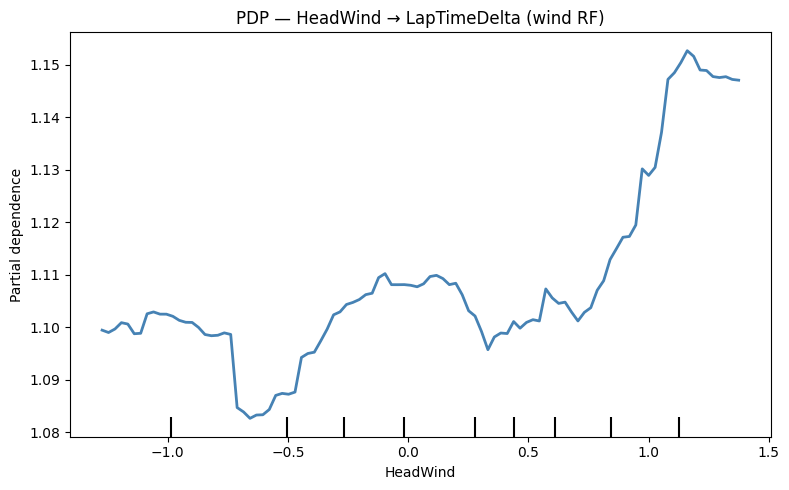

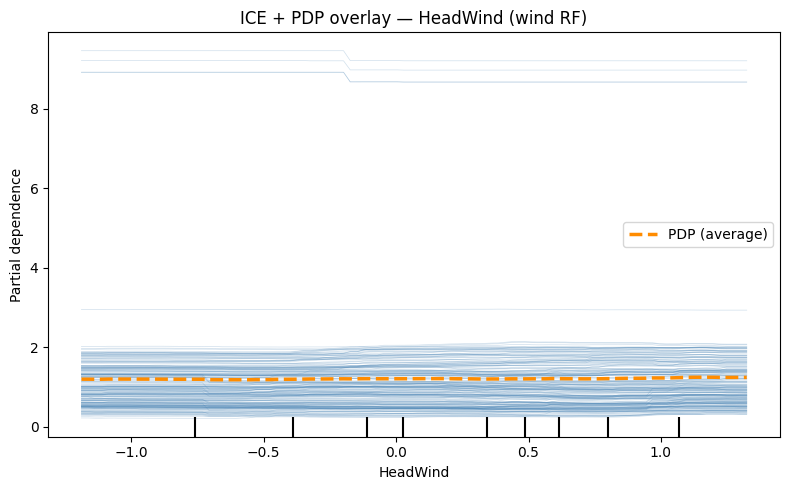

In [4]:
Visualizer.partial_dependence(wind_eval.model, x_wind, "HeadWind",
                              title="PDP — HeadWind → LapTimeDelta (wind RF)")
Visualizer.ice(wind_eval.model, x_wind, "HeadWind",
               title="ICE + PDP overlay — HeadWind (wind RF)")

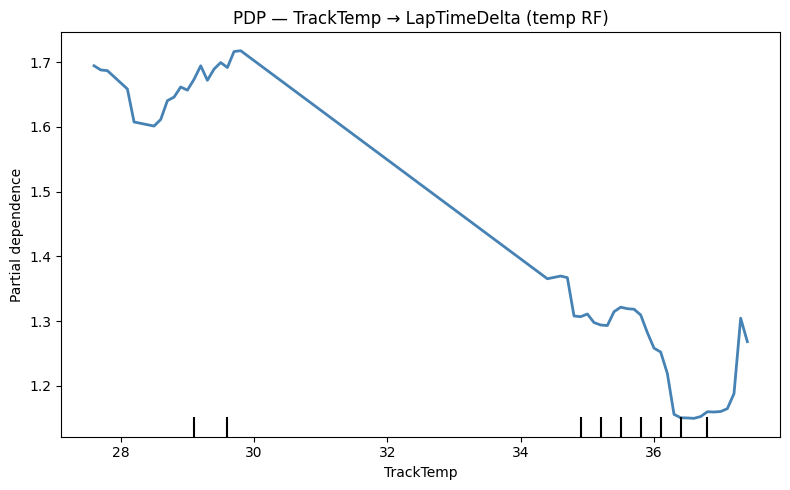

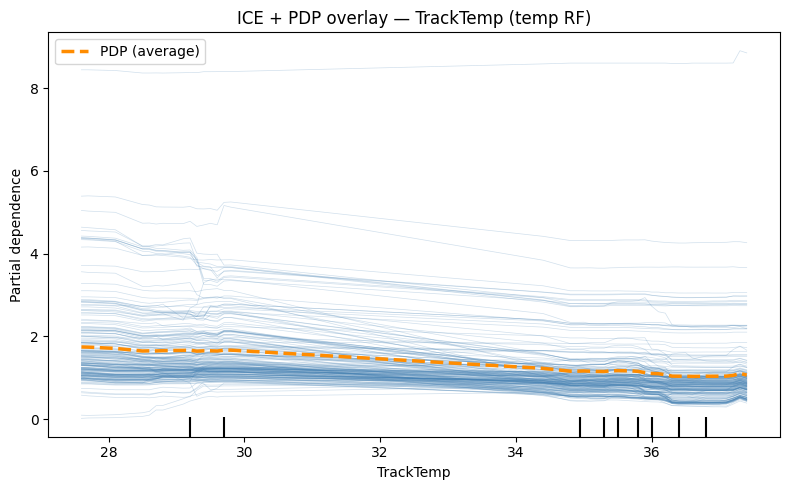

In [5]:
Visualizer.partial_dependence(temp_eval.model, x_temp, "TrackTemp",
                              title="PDP — TrackTemp → LapTimeDelta (temp RF)")
Visualizer.ice(temp_eval.model, x_temp, "TrackTemp",
               title="ICE + PDP overlay — TrackTemp (temp RF)")

## 5. Strategy: the same undercut question, asked twice

A pit-wall undercut call with **identical fixed parameters** for both studies: pit loss 20.0 s, gap to the rival 19.50 s, our new-tyre out-lap 95.20 s, rival old-tyre in-lap 95.50 s, 10 rival laps remaining. Net cost 20.0 + 95.20 − 95.50 = 19.70 s against a 19.50 s gap, so the uncorrected verdict is **CLOSE** in both cases. (These desk parameters are illustrative; the *environmental* conditions below are real 2025 measurements.)

The model contributes one thing only: a per-lap correction Δ = f(current) − f(training mean), read off the PDP by interpolation, and applied **iff** the current condition lies inside the training support. Outside it, the PDP is undefined (the forest's trees never split there), so the correction is withheld rather than extrapolated. The uncorrected arithmetic is always computed; only the model-dependent correction can be refused.

- **Wind:** current condition = Saudi 2025 *measured max* headwind (an undercut is a single-lap decision, so the wind at that moment is what matters; the race mean sits in the flat PDP region).
- **Temp:** current condition = Las Vegas 2025 *measured mean* track temperature, the venue's cold regime.

In [6]:
SCENARIO = dict(pit_loss=20.0, gap=19.50, ours_new_outlap=95.2, rival_old_inlap=95.5, n_remaining=10)

# (1) Wind — Saudi Arabia 2025, cross-domain, in-support
wind_scenario = UndercutScenario(wind_eval.model, x_wind, "HeadWind", **SCENARIO)
_, x_saudi, _ = WindPreprocessor.from_excel(DATA / "2025_Saudi_Arabian_Grand_Prix.xlsx").run()
current_headwind = float(x_saudi["HeadWind"].max())
print(f"current HeadWind = Saudi 2025 measured max = {current_headwind:+.2f} m/s "
      f"(race mean {x_saudi['HeadWind'].mean():+.2f} m/s)")
wind_scenario.evaluate(current_headwind).report()

current HeadWind = Saudi 2025 measured max = +1.38 m/s (race mean -0.31 m/s)

  Feature under study : HeadWind
  Scenario fixed parameters:
    pit_loss              = 20.0 s
    gap (uncorrected)     = 19.50 s
    our new-tyre out-lap  = 95.20 s
    rival old-tyre in-lap = 95.50 s
    rival remaining laps  = 10
    net = pit_loss + ours_new - rival_old = 19.70 s
    uncorrected: net 19.70 vs gap 19.50 (margin -0.20) → CLOSE

  Applicability check (HeadWind):
    training support      = [-2.24, +3.60]
    training mean         = +0.18
    current value         = +1.38
    in support?           = True

  Correction (in-support → applied):
    Δ per lap             = +0.039 s
    Δ over 10 laps        = +0.389 s
    gap (corrected)       = 19.89 s
    corrected: net 19.70 vs gap 19.89 (margin +0.19) → OPEN
    [FLIP] CLOSE → OPEN


In [7]:
# (2) Temp — Las Vegas 2025, cross-domain, OOD
temp_scenario = UndercutScenario(temp_eval.model, x_temp, "TrackTemp", **SCENARIO)
_, x_vegas, _ = TempPreprocessor.from_excel(DATA / "2025_Las_Vegas_Grand_Prix.xlsx").run()
current_tracktemp = float(x_vegas["TrackTemp"].mean())
print(f"current TrackTemp = Vegas 2025 measured mean = {current_tracktemp:.2f} °C")
temp_scenario.evaluate(current_tracktemp).report()

current TrackTemp = Vegas 2025 measured mean = 17.27 °C

  Feature under study : TrackTemp
  Scenario fixed parameters:
    pit_loss              = 20.0 s
    gap (uncorrected)     = 19.50 s
    our new-tyre out-lap  = 95.20 s
    rival old-tyre in-lap = 95.50 s
    rival remaining laps  = 10
    net = pit_loss + ours_new - rival_old = 19.70 s
    uncorrected: net 19.70 vs gap 19.50 (margin -0.20) → CLOSE

  Applicability check (TrackTemp):
    training support      = [+27.60, +37.40]
    training mean         = +34.36
    current value         = +17.27
    in support?           = False

  Correction (OOD → WITHHELD):
    current value +17.27 is outside training support [+27.60, +37.40]
    PDP undefined here → correction NOT applicable → decision CANNOT be evaluated


## 6. What generalized, what refused, and why the asymmetry is the point

- **Wind (Saudi Arabia): correction applied, decision flipped.** The measured max headwind +1.38 m/s lies inside the Baku training support [−2.24, +3.60]. The PDP-derived correction adds about +0.39 s to the gap over 10 laps, and the call flips **CLOSE → OPEN**. A small number, but one with statistical support behind it.
- **Temp (Las Vegas): correction withheld.** The measured mean track temperature 17.27 °C sits far outside the Singapore support [27.60, 37.40]. The forest never split there, the PDP is undefined, so the correction term is refused and no corrected decision is issued. The cross-domain R² of −6.080 from Section 3 confirms empirically what the support check catches structurally: any number emitted at 17 °C would have been wrong.

A black-box predictor would have produced a confident, wrong correction at 17 °C, and the pit wall could not have told the difference. This design detects the out-of-support condition and says so: usable extrapolation when the physics is compatible, honest refusal when it is not. Knowing when not to predict is the contribution.

**Further reading:** [docs/methodology.md](../docs/methodology.md) (data protocol, feature design, model selection, full results) and [docs/retrospective.md](../docs/retrospective.md) (the design decisions behind the refusal, and what they cost).